# 5. Forecasting Framework
The classical forecasting approaches require only the knowledge about lagged target value, whereas the proposed method necessitates availability of additional features (volume, prices, indicators) to extrapolate time-series towards future. Multiple approaches have been proposed, the following <a href="#">report</a> highlights the use case of each.

For the short-term prediction of the baseline model, we implement the autoregressive models **to forecast each of the additional features independently to obtain necessary data for the fit regressor**.

For the short-term prediction of the MVP model, the multivariate regression is applied producing necessary data for future predictions in advance.

This chapter will explore firstly the forecasting of features independently, then assembling new forecasts to produce the general forecasting timeframe, and, finally, develop the interface for forecasting models.

In [1]:
import numpy as np
import pandas as pd
import ta
import datetime
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, MonthLocator, DayLocator, HourLocator, DateFormatter
from numpy.lib.stride_tricks import sliding_window_view
from typing import Tuple, Dict, List, Union, Any, Callable
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.base import BaseEstimator
from abc import ABC, abstractmethod
import joblib
import os

In [2]:
dataset_us_aug = pd.read_csv("data/gold_futures_with_indicators.csv", parse_dates=[0], index_col=0)

## Forecasting Features

In [3]:
dataset_us_aug.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'EMA20', 'RSI14', 'ATR14',
       'MACD', 'MACD_Signal', 'MACD_Hist'],
      dtype='object')

First, remove what is not necessary. The `Close` price is the target which we know how to predict. The `EMA20`, `RSI14`, `ATR14`, `MACD`, `MACD_Signal`, `MACD_Hist` are indicators calculated based on price features. This indicators will be computed based on the forecasted features later.

Finally, we should prepare models for forecasting `High`, `Low`, `Open`, and `Volume` features.

### `High` and `Low` Prices
The time series of these features are not stationary, but the first difference produces stationary series. Therefore, integrator of the first order should be used. Moreover, the $\text{MA}(1)$ and $\text{AR}(1)$ models are proposed based on the analysis for both features. Therefore, the $\text{ARIMA}(1, 1, 1)$ model is applied for the original series:

In [58]:
high_prices_reindexed = dataset_us_aug['High'].asfreq('h')
high_prices_reindexed = high_prices_reindexed.ffill().bfill()

In [59]:
train_size = int(len(high_prices_reindexed) * 0.99)
train_set_high_price, test_set_high_price = high_prices_reindexed.iloc[:train_size], high_prices_reindexed.iloc[train_size:]

In [77]:
high_price_predictor = ARIMA(train_set_high_price, order=(1, 1, 1))

In [78]:
results_high_price = high_price_predictor.fit()
results_high_price.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   High   No. Observations:                17324
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -47808.178
Date:                Sat, 28 Jun 2025   AIC                          95622.356
Time:                        09:10:02   BIC                          95645.635
Sample:                    06-11-2023   HQIC                         95630.025
                         - 06-02-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0673      0.028     -2.382      0.017      -0.123      -0.012
ma.L1          0.1944      0.028      6.984      0.000       0.140       0.249
sigma2        14.6127      0.040    362.939      0.000      14.534      14.692
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            596193.70
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               3.73   Skew:                             0.81
Prob(H) (two-sided):                  0.00   Kurtosis:                        31.69
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Model evaluation**:

In [97]:
y_pred = results_high_price.predict(start=test_set_high_price.index[0], end=test_set_high_price.index[-1], dynamic=False)

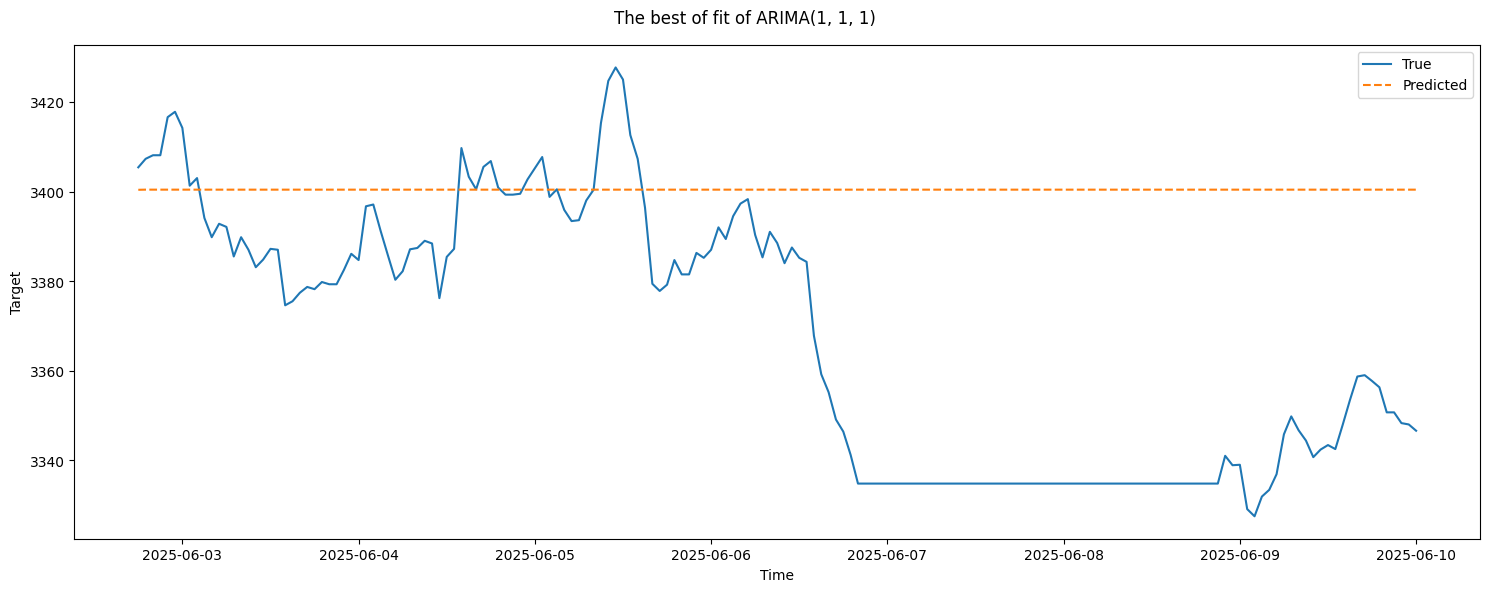

In [98]:
fig, ax = plt.subplots(nrows=1, figsize=(15, 6))
fig.suptitle("The best of fit of ARIMA(1, 1, 1)")

ax.plot(test_set_high_price.index, test_set_high_price, label='True')
ax.plot(test_set_high_price.index, y_pred, label='Predicted', linestyle='--')
ax.set_xlabel("Time")
ax.set_ylabel('Target')
ax.legend()
fig.tight_layout()

In [102]:
low_prices_reindexed = dataset_us_aug['Low'].asfreq('h')
low_prices_reindexed = low_prices_reindexed.ffill().bfill()

In [103]:
train_size = int(len(low_prices_reindexed) * 0.99)
train_set_low_price, test_set_low_price = low_prices_reindexed.iloc[:train_size], low_prices_reindexed.iloc[train_size:]

In [104]:
low_price_predictor = ARIMA(train_set_low_price, order=(1, 1, 1))

In [105]:
results_low_price = low_price_predictor.fit()
results_low_price.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    Low   No. Observations:                17324
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -55380.472
Date:                Sat, 28 Jun 2025   AIC                         110766.943
Time:                        09:18:24   BIC                         110790.223
Sample:                    06-11-2023   HQIC                        110774.613
                         - 06-02-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2499      0.014     18.504      0.000       0.223       0.276
ma.L1         -0.4467      0.013    -33.672      0.000      -0.473      -0.421
sigma2        35.0223      0.118    297.455      0.000      34.792      35.253
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):            356836.14
Prob(Q):                              0.77   Prob(JB):                         0.00
Heteroskedasticity (H):               7.52   Skew:                            -0.50
Prob(H) (two-sided):                  0.00   Kurtosis:                        25.21
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Model evaluation**:

In [106]:
y_pred = results_low_price.predict(start=test_set_low_price.index[0], end=test_set_low_price.index[-1], dynamic=False)

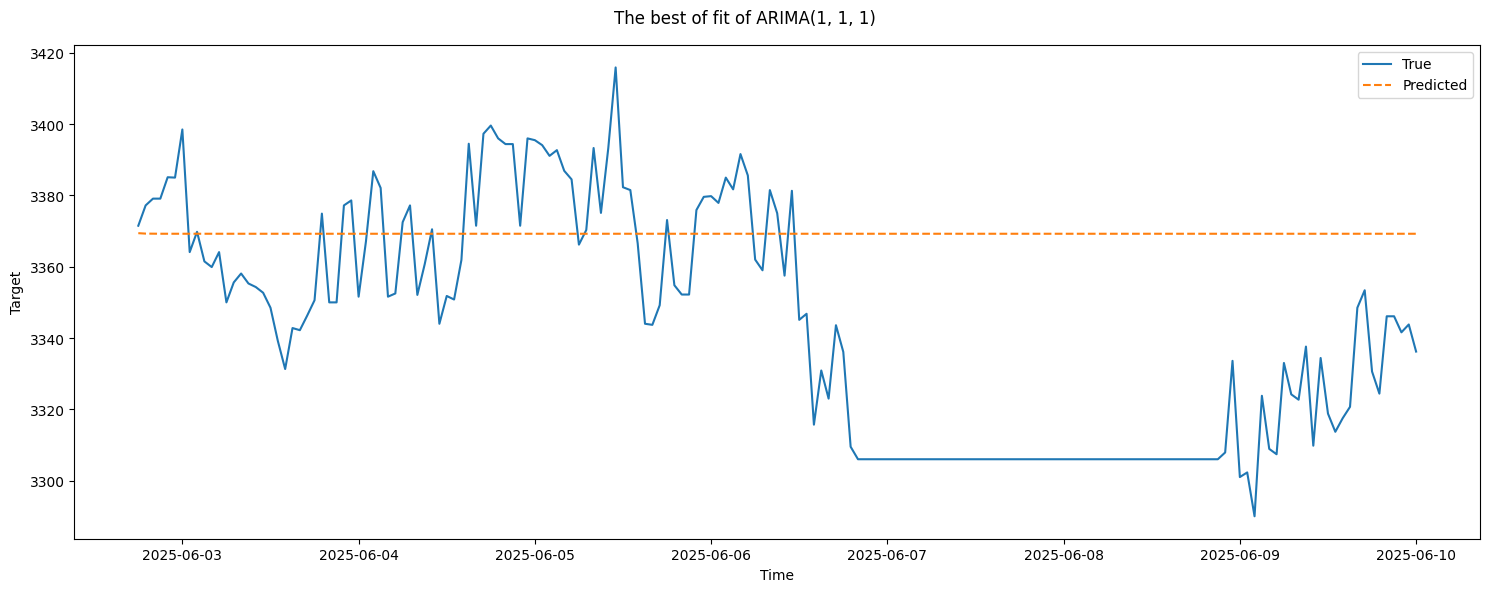

In [107]:
fig, ax = plt.subplots(nrows=1, figsize=(15, 6))
fig.suptitle("The best of fit of ARIMA(1, 1, 1)")

ax.plot(test_set_low_price.index, test_set_low_price, label='True')
ax.plot(test_set_low_price.index, y_pred, label='Predicted', linestyle='--')
ax.set_xlabel("Time")
ax.set_ylabel('Target')
ax.legend()
fig.tight_layout()

### `Volume`

Augment dataset with new features:

In [113]:
df = pd.DataFrame(volume_amt)

# Day of Week (0=Monday, 6=Sunday)
df['day_of_week'] = df.index.dayofweek
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=range(7), ordered=True)

df['year'] = df.index.year
df['year'] = pd.Categorical(df['year'], categories=range(2023, 2026), ordered=True)

# Month (1-12)
month_index = df.index.month

# Cyclical encoding for months (12-month period)
df['month_sin'] = np.sin(2 * np.pi * month_index / 12)
df['month_cos'] = np.cos(2 * np.pi * month_index / 12)

# Season (1=Winter, 2=Spring, 3=Summer, 4=Fall)
df['season'] =  (df.index.month % 12 + 3) // 3
df['season'] = pd.Categorical(df['season'], categories=range(1, 5), ordered=True)

# Weekend flag (1 if Saturday/Sunday, else 0)
df['is_weekend'] = df.index.dayofweek.isin([5, 6]).astype(int)

# Hour (if your data is intraday)
hour_index = df.index.hour

# Cyclical encoding for hours (24h period)
df['hour_sin'] = np.sin(2 * np.pi * hour_index / 24)
df['hour_cos'] = np.cos(2 * np.pi * hour_index / 24)

In [114]:
# For cyclical features (day_of_week, month, season)
df = pd.get_dummies(df, columns=['day_of_week', 'season'], prefix=['dow', 'season'])

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11468 entries, 2023-06-11 22:00:00+00:00 to 2025-06-10 00:00:00+00:00
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Volume      11468 non-null  float64 
 1   year        11468 non-null  category
 2   month_sin   11468 non-null  float64 
 3   month_cos   11468 non-null  float64 
 4   is_weekend  11468 non-null  int32   
 5   hour_sin    11468 non-null  float64 
 6   hour_cos    11468 non-null  float64 
 7   dow_0       11468 non-null  bool    
 8   dow_1       11468 non-null  bool    
 9   dow_2       11468 non-null  bool    
 10  dow_3       11468 non-null  bool    
 11  dow_4       11468 non-null  bool    
 12  dow_5       11468 non-null  bool    
 13  dow_6       11468 non-null  bool    
 14  season_1    11468 non-null  bool    
 15  season_2    11468 non-null  bool    
 16  season_3    11468 non-null  bool    
 17  season_4    11468 non-null  bool    
dtyp

In [116]:
# df['Volume'] = StandardScaler().fit_transform(df[['Volume']])
for feature in ['year', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']:
    df[feature] = MinMaxScaler().fit_transform(df[[feature]])

In [117]:
df.head()

,Volume,year,month_sin,month_cos,is_weekend,hour_sin,hour_cos,dow_0,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6,season_1,season_2,season_3,season_4
Date,,,,,,,,,,,,,,,,,,
2023-06-11 22:00:00+00:00,937.0,0.0,0.5,0.0,1,0.25000,0.933013,False,False,False,False,False,False,True,False,False,True,False
2023-06-11 23:00:00+00:00,1182.0,0.0,0.5,0.0,1,0.37059,0.982963,False,False,False,False,False,False,True,False,False,True,False
2023-06-12 00:00:00+00:00,1453.0,0.0,0.5,0.0,0,0.50000,1.000000,True,False,False,False,False,False,False,False,False,True,False
2023-06-12 01:00:00+00:00,3860.0,0.0,0.5,0.0,0,0.62941,0.982963,True,False,False,False,False,False,False,False,False,True,False
2023-06-12 02:00:00+00:00,2835.0,0.0,0.5,0.0,0,0.75000,0.933013,True,False,False,False,False,False,False,False,False,True,False


In [118]:
X, y = decompose_tabular_data(df.to_numpy(), 25) # lags = 25
X.shape, y.shape

((11443, 468), (11443,))

In [119]:
Xy = pd.DataFrame(X, y)

Model training and evaluation:

In [195]:
# Cross Validation Split
K = 20
tss = TimeSeriesSplit(n_splits=K, test_size=24*10*1, gap=24)

In [196]:
preds = []
Q_mse = 0
Q_mae = 0
Q_mape = 0
Q_R2 = 0

for train_idx, val_idx in tss.split(Xy):
    train = Xy.iloc[train_idx]
    val = Xy.iloc[val_idx]

    X_train, y_train = train.to_numpy(), train.index.to_numpy()
    X_val, y_val = val.to_numpy(), val.index.to_numpy()

    regressor = LinearRegression()

    regressor.fit(X_train, y_train)

    y_pred = regressor.predict(X_val)
    preds.append(y_pred)
    Q_mse += mean_squared_error(y_val, y_pred)
    Q_mae += mean_absolute_error(y_val, y_pred)
    Q_mape += mean_absolute_percentage_error(y_val, y_pred)
    Q_R2 += r2_score(y_val, y_pred)

Q_mse /= K
Q_mae /= K
Q_mape /= K
Q_R2 /= K

In [197]:
print(f"MSE: {Q_mse}, MAE: {Q_mae}, MAPE: {Q_mape}, R2: {Q_R2}")

MSE: 5619728.77637435, MAE: 1757.6425807542055, MAPE: 2.4724776255878768e+17, R2: 0.6217551440598623


In [120]:
dataset_train, dataset_test = df[df.index < '2025-05-01'], df[df.index >= '2025-05-01']

X_train, y_train = decompose_tabular_data(dataset_train.to_numpy(), h=25)
X_test, y_test = decompose_tabular_data(dataset_test.to_numpy(), h=25)

regressor = LinearRegression()

regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred)}, MAE: {mean_absolute_error(y_test, y_pred)}, MAPE: {mean_absolute_percentage_error(y_test, y_pred)}, R2: {r2_score(y_test, y_pred)}")

MSE: 9059813.788225932, MAE: 2213.7780602639505, MAPE: 1.992396222902477e+17, R2: 0.6373167610860548


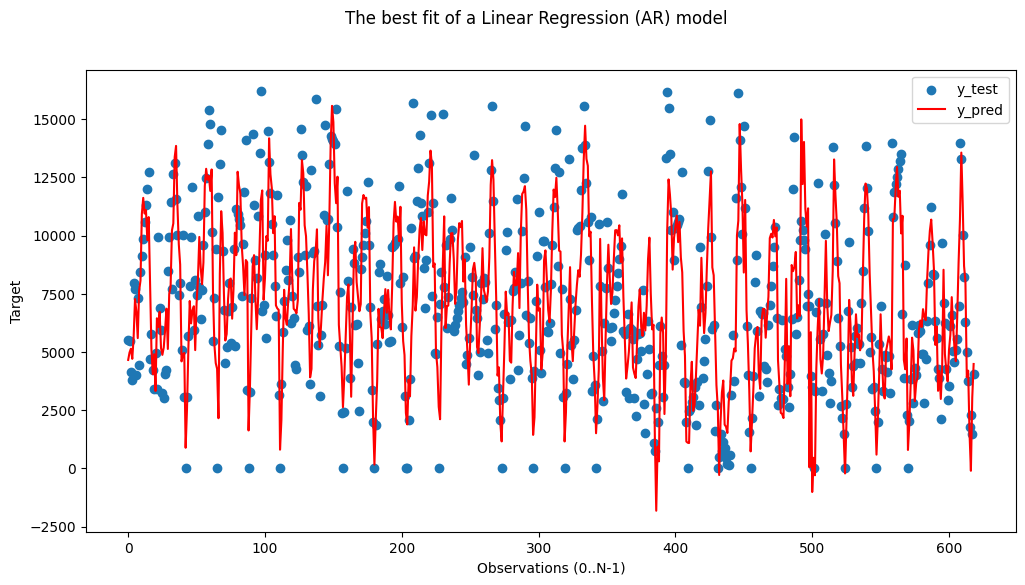

In [199]:
fig, ax = plt.subplots(nrows=1, figsize=(12, 6))
fig.suptitle("The best fit of a Linear Regression (AR) model")

ax.scatter(np.arange(0, len(y_test)), y_test, label='y_test')
ax.plot(np.arange(0, len(y_test)), y_pred, color='red', label='y_pred')
ax.set_xlabel("Observations (0..N-1)")
ax.set_ylabel('Target')
ax.legend()

### `Open` Price
The `Open` price is the lagged time series of the `Close` price. Therefore, the last predicted close price becomes the current open price.

## Time Series Model Class
Different models use distinct feature sets and lags to forecast target. However, the overall forecast should be based only on the existing dataset. To separate the logic of model predictions, a special class is introduced.

In [4]:
class ForecastModel(ABC):
    """
    Class for building dataset, fitting the model, dumping, and loading it.
    """

    @abstractmethod
    def fit(self, df: pd.DataFrame, params: Dict[str, Any]):
        """
        Creates dataset from `df` and fits the model with parameters to the dataset.

        Parameters:
            df (pd.DataFrame): dataframe from which dataset is built.
            params: dictionary of parameter names and values of the model.

        Returns:
            self (ForecastModel)
        """
        pass

    @abstractmethod
    def build(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Builds train/test dataset from the dataframe.

        Parameters:
            df (pd.DataFrame): dataframe from which dataset is built.

        Returns:
            pd.DataFrame: prepared dataset.
        """
        pass

    @abstractmethod
    def build_forecast_data(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Builds dataset from the dataframe to make forecasts.

        Parameters:
            df (pd.DataFrame): dataframe from which dataset is built.

        Returns:
            pd.DataFrame: prepared dataset.
        """
        pass

    @abstractmethod
    def cross_validation(self, df: pd.DataFrame, params: Dict[str, Any], K: int = 20, test_size: int = 24*10*1, metric: Callable = mean_squared_error) -> float:
        """
        K-fold cross validation of a given test size to evaluate model performance.

        Parameters:
            df (pd.DataFrame): dataframe.
            params (params: Dict[str, Any]): parameter names and values.
            K (int): number of folds.
            test_size (int): size of test set (in hours).
            metric (Callable): metric function.

        Returns:
            float: averaged value of metric over folds.
        """
        pass

    @abstractmethod
    def predict(self, date_range: pd.DatetimeIndex) -> pd.Series:
        """
        Creates forecast series of a given date range.

        Parameters:
            date_range (pd.DatetimeIndex): range of dates for index.

        Returns:
            pd.Series: forecasted series.
        """
        pass

    @abstractmethod
    def dump(self, path: str) -> None:
        """
        Saves model to a file.

        Parameters:
            path (str): path to the folder containing file.
        """
        pass

    @abstractmethod
    def load(self, df: pd.DataFrame, path: str) -> None:
        """
        Sets the dataframe and loads the model from a file.

        Parameters:
            df (pd.DataFrame): dataframe from which dataset is built.
            path (str): path to the folder containing file.
        """
        pass

In [5]:
class SLFM(ForecastModel):
    """
    Statistical Lag Forecast Model (ARIMA(1,1,1))

    Attributes:
        feature_name (str): name of the target feature.
        model_ (ARIMA): statistical model.
        model_fit (ARIMAResults): fit model.
    """

    feature_name: str
    model_: ARIMA
    model_fit: ARIMAResults

    def __init__(self, feature_name: str):
        self.feature_name = feature_name
        self.model_ = None
        self.model_fit = None

    def build(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        prices_reindexed = df[self.feature_name].asfreq('h')
        return prices_reindexed

    def build_forecast_data(self, df: pd.DataFrame) -> pd.DataFrame:
        return self.build(df)

    def cross_validation(self, df: pd.DataFrame, params: Dict[str, Any], K: int = 20, test_size: int = 24*10*1, metric: Callable = mean_squared_error) -> float:
        return None

    def fit(self, df: pd.DataFrame):
        df_ = self.build(df)
        self.model_ = ARIMA(df_, order=(1, 1, 1))
        self.model_fit = self.model_.fit()
        return self

    def predict(self, date_range: pd.DatetimeIndex) -> pd.Series:
        assert self.model_fit is not None
        y_pred = self.model_fit.predict(start=date_range[0], end=date_range[-1], dynamic=False)
        return y_pred

    def dump(self, path: str) -> None:
        self.model_fit.save(f"{path}/{self.feature_name}_predictor.joblib")

    def load(self, df: pd.DataFrame, path: str) -> None:
        self.model_fit = ARIMAResults.load(f"{path}/{self.feature_name}_predictor.joblib")

In [6]:
def compose_forecast_frame(data: np.array, features: np.array, lag: int) -> Tuple[np.array, np.array]:
    """
    Compose features from the last observations and features of forecast timeframe.

    For example, [..., y_{n-k}, ..., y_{n-3}, y_{n-2}, y_{n-1}, y_n] (lag=2) would produce

        [*y_{n-1}, *y_{n}, *features, 1].

    Here *a means unpacking values from a vector.

    Parameters:
        data (np.array): 2D-array of target observations.
        features (np.array): 1D-array of current forecast timeframe features.
        lag (int): number of lagged observations to include.

    Returns:
        1D-array of features for the model prediction.
    """
    X = data[-lag:].reshape(-1, lag * data.shape[1])
    X = np.hstack([X, features.reshape(1, -1), np.ones(shape=(X.shape[0], 1))])
    return X

In [7]:
def decompose_data(data: np.array, h: int) -> Tuple[np.array, np.array]:
    """
    Compose features from successive dataset objects using sliding window.

    For example, [y_1, y_2, y_3, y_4, ...] (h=2) would produce

        ([ [y_1, y_2], [y_2, y_3], ...], [y_3, y_4, ...]).

    Parameters:
        data (np.array): 1D-array of target observations.
        h (int): sliding window size.

    Returns:
        Tuple[np.array, np.array]: tuple of sampled dataset of h features
        and the target value for them.
    """
    X = sliding_window_view(data, window_shape=h)[:-1, :]
    X = np.concatenate((X, np.ones(shape=(len(X), 1))), axis=1)
    y = data[h:]
    return (X, y)

In [8]:
def decompose_tabular_data(data: np.array, h: int) -> Tuple[np.array, np.array]:
    """
    Compose features from successive dataset objects using sliding window.

    For example, [y_1, y_2, y_3, y_4, ...] (h=2) would produce

        ([ [*y_1, *y_2, y_3[:, 1:]], [*y_2, *y_3, y_4[:, 1:]], ...], [y_3, y_4, ...]).

    Here *a means unpacking values from a vector.

    Parameters:
        data (np.array): 2D-array of target observations.
        h (int): sliding window size.

    Returns:
        Tuple[np.array, np.array]: tuple of sampled dataset of h features
        and the target value for them.
    """
    X = sliding_window_view(data, window_shape=(h, data.shape[1])).reshape(-1, h * data.shape[1])[:-1, :]
    y = data[h:]
    target, features = y[:, 0], y[:, 1:]
    X = np.hstack([X, features, np.ones(shape=(X.shape[0], 1))])
    return (X, target)

In [34]:
class VolumeFM(ForecastModel):
    """
    Forecasting model for `Volume` target.

    Model selected: XGBRegressor

    Attributes:
        model_ (BaseEstimator): regression model.
        df_ (pd.DataFrame): dataset built for training
        lag (int): number of lagged features.
    """

    model_: BaseEstimator
    df_: pd.DataFrame
    lag: int

    def __init__(self, lag: int = 25):
        self.lag = lag

    def preprocess_(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Preprocessing of dataframe before building.

        Parameter:
            df (pd.DataFrame): dataframe.

        Returns:
            pd.DataFrame: preprocessed dataframe.
        """

        df = df.copy()
        
        Q1, Q3 = df.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        outliers = (df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))

        df.loc[outliers] = np.nan
        df = df.interpolate(method='time')

        return df

    def build(self, df: pd.DataFrame) -> pd.DataFrame:

        df = df.copy()

        df = pd.DataFrame(self.preprocess_(df['Volume']))

        # Day of Week (0=Monday, 6=Sunday)
        df['day_of_week'] = df.index.dayofweek
        df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=range(7), ordered=True)

        df['year'] = df.index.year
        df['year'] = pd.Categorical(df['year'], categories=range(2023, 2026), ordered=True)

        # Month (1-12)
        month_index = df.index.month

        # Cyclical encoding for months (12-month period)
        df['month_sin'] = np.sin(2 * np.pi * month_index / 12)
        df['month_cos'] = np.cos(2 * np.pi * month_index / 12)

        # Season (1=Winter, 2=Spring, 3=Summer, 4=Fall)
        df['season'] = (df.index.month % 12 + 3) // 3
        df['season'] = pd.Categorical(df['season'], categories=range(1, 5), ordered=True)

        # Weekend flag (1 if Saturday/Sunday, else 0)
        df['is_weekend'] = df.index.dayofweek.isin([5, 6]).astype(int)

        # Hour
        hour_index = df.index.hour

        # Cyclical encoding for hours (24h period)
        df['hour_sin'] = np.sin(2 * np.pi * hour_index / 24)
        df['hour_cos'] = np.cos(2 * np.pi * hour_index / 24)

        # For cyclical features (day_of_week, season)
        df = pd.get_dummies(df, columns=['day_of_week', 'season'], prefix=['dow', 'season'])

        # Normalization
        for feature in ['year', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']:
            df[feature] = MinMaxScaler().fit_transform(df[[feature]])

        return df

    def build_forecast_data(self, df: pd.DataFrame):
        """
        Builds forecasting dataset (indexed with forecasting date range) from the dataframe.

        Parameters:
            df (pd.DataFrame): dataframe from which dataset is built.

        Returns:
            pd.DataFrame: prepared dataset.
        """

        df = df.copy()

        df = pd.DataFrame(df['Volume'])

        # Day of Week (0=Monday, 6=Sunday)
        df['day_of_week'] = df.index.dayofweek
        df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=range(7), ordered=True)

        df['year'] = df.index.year
        df['year'] = pd.Categorical(df['year'], categories=range(2023, 2026), ordered=True)

        # Month (1-12)
        month_index = df.index.month

        # Cyclical encoding for months (12-month period)
        df['month_sin'] = np.sin(2 * np.pi * month_index / 12)
        df['month_cos'] = np.cos(2 * np.pi * month_index / 12)

        # Season (1=Winter, 2=Spring, 3=Summer, 4=Fall)
        df['season'] = (df.index.month % 12 + 3) // 3
        df['season'] = pd.Categorical(df['season'], categories=range(1, 5), ordered=True)

        # Weekend flag (1 if Saturday/Sunday, else 0)
        df['is_weekend'] = df.index.dayofweek.isin([5, 6]).astype(int)

        # Hour
        hour_index = df.index.hour

        # Cyclical encoding for hours (24h period)
        df['hour_sin'] = np.sin(2 * np.pi * hour_index / 24)
        df['hour_cos'] = np.cos(2 * np.pi * hour_index / 24)

        # For cyclical features (day_of_week, season)
        df = pd.get_dummies(df, columns=['day_of_week', 'season'], prefix=['dow', 'season'])

        # Normalization
        for feature in ['year', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']:
            df[feature] = MinMaxScaler().fit_transform(df[[feature]])

        return df

    def cross_validation(self, df: pd.DataFrame, params: Dict[str, Any], K: int = 20, test_size: int = 24*10*1, metric: Callable = mean_squared_error) -> float:
        history_df = self.build(df)

        tss = TimeSeriesSplit(n_splits=K, test_size=test_size, gap=24)

        X_train, y_train = decompose_tabular_data(history_df.to_numpy(), h=self.lag)
        Xy = pd.DataFrame(X_train, y_train)

        score = 0
        
        for train_idx, val_idx in tss.split(Xy):
            train = Xy.iloc[train_idx]
            val = Xy.iloc[val_idx]
            
            X_train, y_train = train.to_numpy(), train.index.to_numpy()
            X_val, y_val = val.to_numpy(), val.index.to_numpy()
            
            regressor = XGBRegressor(
                learning_rate=params['learning_rate'],
                max_depth=params['max_depth'],
                min_child_weight=params['min_child_weight'],
                subsample=params['subsample'],
                colsample_bytree=params['colsample_bytree'],
                gamma=params['gamma'],
                scale_pos_weight=np.sqrt(len(y_train)/y_train.sum()),
                tree_method='hist',
                booster='gbtree',
                objective='reg:squarederror',
                random_state=42
            )

            regressor.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
            
            y_pred = regressor.predict(X_val)

            score += metric(y_val, y_pred)
        
        return score / K

    def fit(
        self,
        df: pd.DataFrame,
        params: Dict[str, Union[float, str]] = {
            "learning_rate": 0.03,
            "max_depth": 6,
            "min_child_weight": 7.24,
            "subsample": 0.51,
            "colsample_bytree": 0.68,
            "gamma": 2.84
        }
    ):
        self.df_ = self.build(df)

        train_size = int(len(self.df_) * 0.8)
        train_set, test_set = self.df_.iloc[:train_size], self.df_.iloc[train_size:]

        X_train, y_train = decompose_tabular_data(train_set.to_numpy(), h=self.lag)
        X_test, y_test = decompose_tabular_data(test_set.to_numpy(), h=self.lag)
        
        self.model_ = XGBRegressor(
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            min_child_weight=params['min_child_weight'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            gamma=params['gamma'],
            scale_pos_weight=np.sqrt(len(y_train)/y_train.sum()),
            tree_method='hist',
            booster='gbtree',
            objective='reg:squarederror',
            random_state=42
        )

        self.model_.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
        
        return self

    def predict(self, date_range: pd.DatetimeIndex) -> pd.Series:

        prediction_df = self.build_forecast_data(pd.DataFrame(index=date_range, columns=['Volume']))

        history_df = self.df_.copy()
        
        for date in date_range:
            feature_columns = [column for column in prediction_df.columns if column != 'Volume']
            features = prediction_df.loc[date, feature_columns].copy()
            
            x_ = compose_forecast_frame(history_df.to_numpy(), features.to_numpy(), self.lag)
            y_ = self.model_.predict(x_)

            features.loc['Volume'] = y_
            history_df = pd.concat([history_df, features.to_frame().T])

        return history_df.loc[date_range[0]:date_range[-1], 'Volume']

    def dump(self, path: str) -> None:
        joblib.dump(self.model_, f"{path}/Volume_predictor.joblib")

    def load(self, df: pd.DataFrame, path: str):
        self.df_ = self.build(df)
        self.model_ = joblib.load(f"{path}/Volume_predictor.joblib")

In [35]:
class ClosePriceFM(ForecastModel):
    """
    Forecasting model for `Close` target.

    Selected model: XGBRegressor.

    Attributes:
        model_ (BaseEstimator): regression model.
        feature_models (Dict[str, ForecastModel]): dictionary of auxiliary models and their names.
        df_ (pd.DataFrame): dataset built for training.
        last_close_price (float): price of the last observed close prices.
        lag (int): number of lagged features.
        indicators (List[str]): names of indicators.
    """

    model_: BaseEstimator
    feature_models: Dict[str, ForecastModel]
    df_: pd.DataFrame
    last_close_price: float
    lag: int
    train_size: float
    indicators: List[str] = ['EMA20', 'RSI14', 'ATR14', 'MACD', 'MACD_Signal', 'MACD_Hist']

    def __init__(self, lag: int = 25, train_size: float = 0.7):
        self.lag = lag
        self.train_size = 0.7
        self.feature_models = {
            'High': SLFM('High'),
            'Low': SLFM('Low'),
            'Volume': VolumeFM()
        }

    def build(self, df: pd.DataFrame):

        df = df.copy()

        # First difference to remove trend
        self.last_close_price = df['Close'].iloc[-1]
        df.loc[:, 'Close'] = df['Close'].diff()
        df = df.dropna()

        # Day of Week (0=Monday, 6=Sunday)
        df['day_of_week'] = df.index.dayofweek
        df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=range(7), ordered=True)

        df['year'] = df.index.year
        df['year'] = pd.Categorical(df['year'], categories=range(2023, 2026), ordered=True)

        # Month (1-12)
        month_index = df.index.month

        # Cyclical encoding for months (12-month period)
        df['month_sin'] = np.sin(2 * np.pi * month_index / 12)
        df['month_cos'] = np.cos(2 * np.pi * month_index / 12)

        # Season (1=Winter, 2=Spring, 3=Summer, 4=Fall)
        df['season'] = (df.index.month % 12 + 3) // 3
        df['season'] = pd.Categorical(df['season'], categories=range(1, 5), ordered=True)

        # Weekend flag (1 if Saturday/Sunday, else 0)
        df['is_weekend'] = df.index.dayofweek.isin([5, 6]).astype(int)

        # Hour
        hour_index = df.index.hour

        # Cyclical encoding for hours (24h period)
        df['hour_sin'] = np.sin(2 * np.pi * hour_index / 24)
        df['hour_cos'] = np.cos(2 * np.pi * hour_index / 24)

        # For cyclical features (day_of_week, season)
        df = pd.get_dummies(df, columns=['day_of_week', 'season'], prefix=['dow', 'season'])

        # Normalization
        for feature in ['year', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']:
            df[feature] = MinMaxScaler().fit_transform(df[[feature]])

        return df

    def build_forecast_data(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Builds forecasting dataset (indexed with forecasting date range) from the dataframe.

        Parameters:
            df (pd.DataFrame): dataframe from which dataset is built.

        Returns:
            pd.DataFrame: prepared dataset.
        """

        df = df.copy()

        # Predict feature targets
        for feature, feature_model in self.feature_models.items():
            df.loc[:, feature] = feature_model.predict(df.index)
        # Set `Open` price
        df.loc[:, 'Open'] = np.nan
        df.loc[df.index[0], 'Open'] = self.df_['Close'].iloc[-1]

        # Set `Close` price
        df.loc[:, 'Close'] = np.nan

        # Day of Week (0=Monday, 6=Sunday)
        df['day_of_week'] = df.index.dayofweek
        df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=range(7), ordered=True)

        df['year'] = df.index.year
        df['year'] = pd.Categorical(df['year'], categories=range(2023, 2026), ordered=True)

        # Month (1-12)
        month_index = df.index.month

        # Cyclical encoding for months (12-month period)
        df['month_sin'] = np.sin(2 * np.pi * month_index / 12)
        df['month_cos'] = np.cos(2 * np.pi * month_index / 12)

        # Season (1=Winter, 2=Spring, 3=Summer, 4=Fall)
        df['season'] = (df.index.month % 12 + 3) // 3
        df['season'] = pd.Categorical(df['season'], categories=range(1, 5), ordered=True)

        # Weekend flag (1 if Saturday/Sunday, else 0)
        df['is_weekend'] = df.index.dayofweek.isin([5, 6]).astype(int)

        # Hour
        hour_index = df.index.hour

        # Cyclical encoding for hours (24h period)
        df['hour_sin'] = np.sin(2 * np.pi * hour_index / 24)
        df['hour_cos'] = np.cos(2 * np.pi * hour_index / 24)

        # For cyclical features (day_of_week, season)
        df = pd.get_dummies(df, columns=['day_of_week', 'season'], prefix=['dow', 'season'])

        # Normalization
        for feature in ['year', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']:
            df[feature] = MinMaxScaler().fit_transform(df[[feature]])

        # Set Indicators
        for indicator in self.indicators:
            df.loc[:, indicator] = np.nan
            df.loc[df.index[0], indicator] = self.df_[indicator].iloc[-1]

        return df

    def cross_validation(self, df: pd.DataFrame, params: Dict[str, Any], K: int = 20, test_size: int = 24*10*1, metric: Callable = mean_squared_error) -> float:
        history_df = self.build(df)

        tss = TimeSeriesSplit(n_splits=K, test_size=test_size, gap=24)

        X_train, y_train = decompose_tabular_data(history_df.to_numpy(), h=self.lag)
        Xy = pd.DataFrame(X_train, y_train)

        score = 0
        
        for train_idx, val_idx in tss.split(Xy):
            train = Xy.iloc[train_idx]
            val = Xy.iloc[val_idx]
            
            X_train, y_train = train.to_numpy(), train.index.to_numpy()
            X_val, y_val = val.to_numpy(), val.index.to_numpy()
            
            regressor = XGBRegressor(
                learning_rate=params['learning_rate'],
                max_depth=params['max_depth'],
                min_child_weight=params['min_child_weight'],
                subsample=params['subsample'],
                colsample_bytree=params['colsample_bytree'],
                gamma=params['gamma'],
                scale_pos_weight=np.sqrt(len(y_train)/y_train.sum()),
                tree_method='hist',
                booster='gbtree',
                objective='reg:squarederror',
                random_state=42
            )

            regressor.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
            
            y_pred = regressor.predict(X_val)

            score += metric(y_val, y_pred)
        
        return score / K

    def fit(
        self,
        df: pd.DataFrame,
        params: Dict[str, Union[float, str]] = {
            "learning_rate": 0.25,
            "max_depth": 6,
            "min_child_weight": 6.64,
            "subsample": 0.997,
            "colsample_bytree": 0.95,
            "gamma": 2.03
        }
    ):
        self.df_ = self.build(df)

        # Fit feature models
        for feature_model in self.feature_models.values():
            feature_model.fit(df)

        train_size = int(len(self.df_) * self.train_size)
        train_set, test_set = self.df_.iloc[:train_size], self.df_.iloc[train_size:]

        X_train, y_train = decompose_tabular_data(train_set.to_numpy(), h=self.lag)
        X_test, y_test = decompose_tabular_data(test_set.to_numpy(), h=self.lag)
        
        self.model_ = XGBRegressor(
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            min_child_weight=params['min_child_weight'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            gamma=params['gamma'],
            scale_pos_weight=np.sqrt(len(y_train)/y_train.sum()),
            tree_method='hist',
            booster='gbtree',
            objective='reg:squarederror',
            random_state=42,
        )

        self.model_.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
        
        return self

    def predict(self, date_range: pd.DatetimeIndex) -> pd.Series:

        prediction_df = self.build_forecast_data(pd.DataFrame(index=date_range))

        history_df = self.df_.copy()

        for idx, date in enumerate(date_range):

            feature_columns = [column for column in prediction_df.columns if column != 'Close']
            features = prediction_df.loc[date, feature_columns].copy()
            
            x_ = compose_forecast_frame(history_df.to_numpy(), features.to_numpy(), self.lag)
            y_ = self.model_.predict(x_)

            history_close_price = pd.concat([history_df['Close'], pd.Series(y_, index=[date])])
            history_high_price = pd.concat([history_df['High'], pd.Series(features['High'], index=[date])])
            history_low_price = pd.concat([history_df['Low'], pd.Series(features['Low'], index=[date])])

            # Indicators
            features.loc['EMA20'] = ta.trend.EMAIndicator(history_close_price, window=20).ema_indicator().iloc[-1]
            features.loc['RSI14'] = ta.momentum.RSIIndicator(history_close_price, window=14).rsi().iloc[-1]
            features.loc['ATR14'] = ta.volatility.AverageTrueRange(history_high_price, history_low_price, history_close_price, window=14).average_true_range().iloc[-1]
            
            macd = ta.trend.MACD(history_close_price, window_slow=26, window_fast=12, window_sign=9)
            features.loc['MACD'] = macd.macd().iloc[-1]
            features.loc['MACD_Signal'] = macd.macd_signal().iloc[-1]
            features.loc['MACD_Hist'] = macd.macd_diff().iloc[-1]

            # Set future indicator values as current
            if idx < len(date_range)-1:
                for indicator in self.indicators:
                    prediction_df.loc[date_range[idx+1], indicator] = features[indicator]
                # Set `Open` price
                prediction_df.loc[date_range[idx+1], 'Open'] = history_df['Close'].iloc[-1]

            features.loc['Close'] = y_
            history_df = pd.concat([history_df, pd.DataFrame.from_records([features], index=[date])])

        # Recover original time series
        y_pred = history_df.loc[date_range[0]:date_range[-1], 'Close']
        price_prediction = self.last_close_price + np.cumsum(y_pred)

        return price_prediction

    def dump(self, path: str) -> None:
        joblib.dump(self.model_, f"{path}/Close_predictor.joblib")
        for model in self.feature_models.values():
            model.dump(path)

    def load(self, df: pd.DataFrame, path: str):
        self.df_ = self.build(df.copy())
        self.model_ = joblib.load(f"{path}/Close_predictor.joblib")
        for model in self.feature_models.values():
            model.load(df, path)

## Iterative Forecast
To facilitate the abstraction of prediction models and reusability, the following framework is proposed:

In [36]:
class ForecastFramework:
    """
    Class for creating, maintaining, dumping, and loading forecasting models.

    Attributes:
        df (pd.DataFrame): dataframe for models.
        forecast_model (ForecastModel): model forecasting target.
    """
    df: pd.DataFrame
    target_columns: pd.DataFrame
    train_set: pd.DataFrame
    test_set: pd.DataFrame
    forecast_model: ForecastModel

    def __init__(
            self,
            df: pd.DataFrame,
            target_columns=['Close'],
            forecast_model=ClosePriceFM(),
            name="baseline_model",
            train_size = 0.7
    ):
        self.df = df.copy()
        self.df = self.df.asfreq('h').bfill().ffill()
        
        self.target_columns = target_columns

        train_size = int(len(self.df) * train_size)
        self.train_set, self.test_set = self.df.iloc[:train_size], self.df.iloc[train_size:]
        
        self.forecast_model = forecast_model
        self.name = name

    def train_model(self) -> None:
        """
        Fits the model with dataframe.
        """
        self.forecast_model.fit(self.train_set)

    def evaluate(self, metric_funcs = {'MAE': mean_absolute_error, 'MSE': mean_squared_error}):
        """
        Evaluates model on the test set.
        """
        forecast_values = self.forecast_model.predict(self.test_set.index).to_numpy().reshape(-1)
        true_values = self.test_set[self.target_columns].to_numpy()
        results = dict(keys=metric_funcs.keys())
        for metric, func in metric_funcs.items():
            results[metric] = func(true_values, forecast_values)
        return results

    def plot_forecast(self):
        """
        Plots forecasted data on the test interval as well as the true values.
        """
        forecast_values = self.forecast_model.predict(self.test_set.index).to_numpy().reshape(-1)
        true_values = self.test_set[self.target_columns].to_numpy()

        fig, ax = plt.subplots(nrows=true_values.shape[1], figsize=(12, 8), squeeze=False)

        for target_idx in range(true_values.shape[1]):
            ax[target_idx, 0].plot(self.test_set.index, true_values)
            ax[target_idx, 0].plot(self.test_set.index, forecast_values, linestyle='--')
            ax[target_idx, 0].xaxis.set_major_locator(DayLocator(interval=1))
            ax[target_idx, 0].xaxis.set_major_formatter(DateFormatter('%m-%d'))
            ax[target_idx, 0].set_ylabel(self.target_columns[target_idx])
        return fig


    def dump_model(self, path: str = None) -> None:
        """
        Dumps the model to the given path.

        Parameters:
            path (str): path to the folder to store model files.
        """
        if path is None:
            path = self.name
        if not os.path.exists(path):
            os.mkdir(path)
        self.forecast_model.dump(path=path)
    
    def load_from_file(
        path: str,
        df: pd.DataFrame,
        target_columns=['Close'],
        forecast_model: ForecastModel = ClosePriceFM(),
        name="baseline_model",
        train_size=0.7
    ):
        """
        (Constructor)
        Loads the model from the given path with the dataframe.

        Parameters:
            path (str): path to the folder with model files.
            df (pd.DataFrame): dataframe for model fitting.
            target_columns (List[str]): list of columns predicted.
            forecast_model (ForecastModel): model forecasting target.
            name (str): name of the model.
            train_size (float): ratio of train set size.

        Returns:
            ForecastFramework: constructed framework object.
        """
        assert os.path.exists(path)
        framework = ForecastFramework(df, target_columns, forecast_model, name, train_size)
        framework.forecast_model.load(framework.train_set, path)
        return framework

    def create_forecast(self, value: int = 1, unit: str = 'd') -> pd.Series:
        """
        Predict values from the last observation by value units of time.

        Parameters:
            value (int): number of units.
            unit (str): unit of time (e.g. 'h', 'd', 'm')

        Returns:
            pd.Series: forecasted values.
        """
        date_range = self.forecast_interval_(value, unit)
        return self.forecast_model.predict(date_range)

    def forecast_interval_(self, value: int, unit: str) -> pd.DatetimeIndex:
        """
        Produces date range from the last available observation + 1 hour
        to the date after `value` number of `unit`s.
        
        Parameters:
            value (int): number of units.
            unit (str): unit of time (e.g. 'h', 'd', 'm')
        
        Returns:
            pd.DatetimeIndex: date range for forecasting model.
        """
        date_index = self.df.index
        return pd.date_range(
            date_index[-1] + pd.Timedelta(value=1, unit='h'),
            date_index[-1] + pd.Timedelta(value=1, unit='h') + pd.Timedelta(value=value, unit=unit),
            freq='h'
        )

## Evaluation of Baseline model

In [37]:
fm = ForecastFramework(dataset_us_aug, train_size=0.7)

In [38]:
fm.train_model()

In [39]:
fm.dump_model()

In [40]:
fm_1 = ForecastFramework.load_from_file(path="baseline_model", df=dataset_us_aug)

In [ ]:
res = fm.evaluate()

In [31]:
res

{'keys': dict_keys(['MAE', 'MSE']),
 'MAE': 41213.88174972098,
 'MSE': 2277247122.8347955}

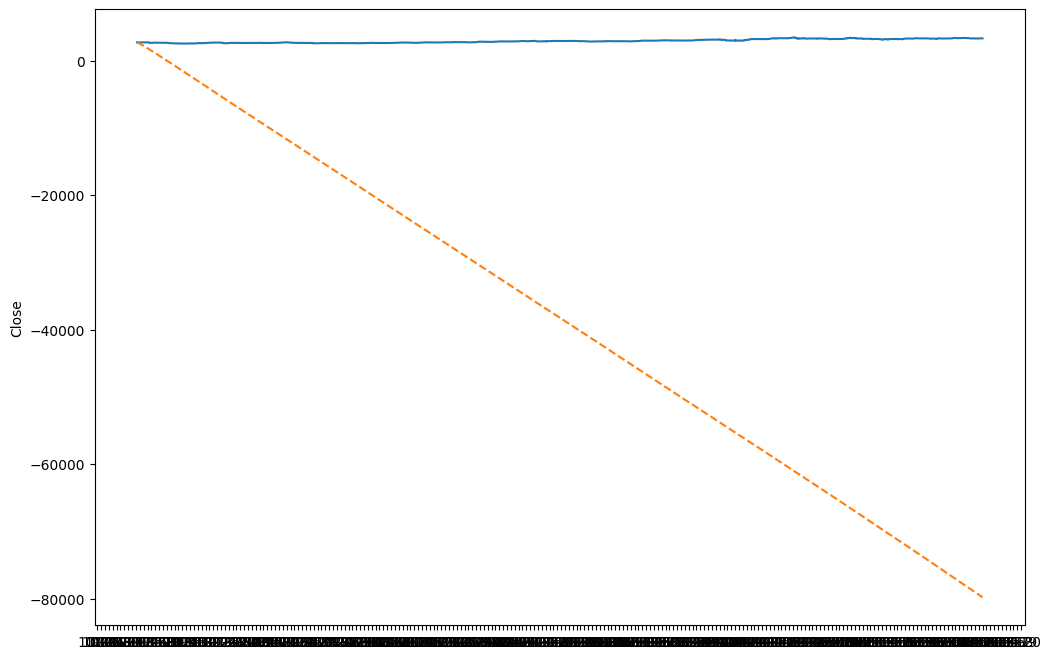

In [41]:
_ = fm_1.plot_forecast()